# 04 - LSM + CAP age x sex calibration (pooled 60+)

This is the fit the simulation consumes. For each (sex, 5-year age band) of adults
**60+** on the pooled 2017-2023 sample we produce:

- **LSM**: a two-parameter **lognormal** whose `(mean_kpa, sd_kpa)` the downstream
  loader reads. Rather than matching the arithmetic moments or a single F4 tail,
  we choose `(mu, sigma)` to **minimise the weighted squared error of the fibrosis
  stage shares (F0-F4)**, with F1/F2/F3 weighted above F0/F4. Those stage shares
  are exactly the routing fractions the simulation applies, so this pins what
  matters. Stage cutoffs: **6 / 8 / 10 / 15 kPa**.
- **CAP**: a moment-matched **Normal** `(cap_mean, cap_sd)` (CAP is roughly
  symmetric; no stage calibration, per project decision).

Two refinements over the old F4-only calibration:

1. **Small-cell smoothing.** F3/F4 counts fall to single digits in the oldest
   cells, so we smooth each cutoff's cumulative share across age within sex (logit
   space, effective-N weighted, low order) and calibrate to the smoothed targets.
2. **Top-coded age.** NHANES codes age 80 as 80+, so the terminal band is drawn
   as an open-ended `80+` cell (`age_start=80, age_end=125`), not a 5-year bin.

All fit logic lives in `lsm_cap_fit.py`. The fitted range is 60+ (the trial
enrols 65-80; 60-64 gives a buffer). Notebook 05 forward-fills the younger
skeleton rows the strict loader requires.


In [1]:
import warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import lsm_cap_fit as L
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

pool = pd.read_parquet(L.POOLED_PARQUET)
lsm = L.assign_band(L.analysis_frame(pool, 'LSM'))
cap = L.assign_band(L.analysis_frame(pool, 'CAP'))
lsm60 = lsm[lsm['age_years'] >= 60]
cap60 = cap[cap['age_years'] >= 60]
BANDS = L.band_edges(start=60, top=80)          # (age_start, age_end, label), 80+ terminal
BAND_MID = {60.0: 62, 65.0: 67, 70.0: 72, 75.0: 77, 80.0: 82}
print(f'LSM 60+: {len(lsm60):,} | CAP 60+: {len(cap60):,}')
print('fitted bands:', [b[2] for b in BANDS])


LSM 60+: 5,005 | CAP 60+: 5,005
fitted bands: ['60-64', '65-69', '70-74', '75-79', '80+']


## 1. Empirical per-cell targets

For each cell: n, effective N, weighted mean/SD/median, the cumulative shares at
the ladder cutoffs (calibration targets), and the F0-F4 stage shares. Note how
F2 (narrow 8-10 band) often sits below F3 (wide 10-15 band) in the male cells --
a shoulder no single lognormal reproduces exactly.


In [2]:
rows = []
for sex in ['Female', 'Male']:
    for lo, hi, lab in BANDS:
        sub = lsm60[(lsm60['sex'] == sex) & (lsm60['age_start'] == lo)]
        if len(sub) < 30:
            continue
        y, w = sub['LSM_KPA'].values.astype(float), sub['MEC_WT_POOL'].values.astype(float)
        cum = L.empirical_cum_at(y, w, L.LSM_CUTOFFS)
        sh = L.empirical_stage_shares(y, w, L.LSM_CUTOFFS)
        rows.append(dict(sex=sex, age_start=lo, age_end=hi, age_group=lab,
                         top_coded=(lo == 80.0), n=len(sub), n_eff=L.n_eff(w),
                         mean=L.w_mean(y, w), sd=L.w_sd(y, w), median=L.w_quantile(y, w, .5),
                         **{f'cum_{c:g}': cum[i] for i, c in enumerate(L.LSM_CUTOFFS)},
                         **{f'{st}_share': sh[i] for i, st in enumerate(L.LSM_STAGES)}))
emp = pd.DataFrame(rows)
show = ['sex', 'age_group', 'n', 'n_eff', 'mean', 'sd', 'median'] + [f'{s}_share' for s in L.LSM_STAGES]
print(emp[show].assign(**{f'{s}_share': (emp[f'{s}_share'] * 100).round(1) for s in L.LSM_STAGES})
      .round(2).to_string(index=False))


   sex age_group   n  n_eff  mean   sd  median  F0_share  F1_share  F2_share  F3_share  F4_share
Female     60-64 778 373.15  5.78 5.12    4.70      72.7      16.4       4.3       4.5       2.0
Female     65-69 659 345.32  5.80 3.92    5.00      70.9      16.5       5.2       5.2       2.2
Female     70-74 485 319.56  5.88 4.08    4.91      69.6      17.5       5.8       3.9       3.2
Female     75-79 319 220.49  5.59 3.12    4.92      72.9      18.8       4.0       2.2       2.1
Female       80+ 328 236.73  5.62 2.95    5.00      70.7      19.8       4.5       2.1       2.9
  Male     60-64 760 336.14  6.93 7.62    5.40      63.1      21.5       6.3       5.3       3.7
  Male     65-69 557 256.47  6.43 4.66    5.30      59.8      24.7       4.9       7.2       3.4
  Male     70-74 493 309.66  7.69 9.64    5.50      57.4      23.6       6.7       7.0       5.3
  Male     75-79 287 187.31  6.70 6.71    5.43      61.7      24.6       3.8       6.6       3.3
  Male       80+ 339 233.39  6

## 2. Smooth the calibration targets across age

Each cutoff's cumulative share is smoothed across the age bands within a sex, in
logit space, weighted by effective N and low-order in age. This tames the
single-digit-count noise in the oldest cells while preserving the real age
gradient. We calibrate the lognormal to these smoothed cumulative shares.


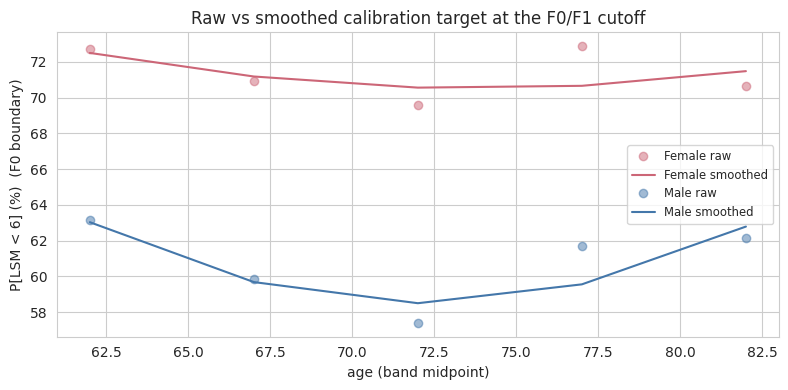

In [3]:
cutcols = [f'cum_{c:g}' for c in L.LSM_CUTOFFS]
smoothed = {}
for sex in ['Female', 'Male']:
    s = emp[emp['sex'] == sex].sort_values('age_start')
    ages = s['age_start'].map(BAND_MID).values.astype(float)
    cum = s[cutcols].values
    neff = s['n_eff'].values
    sm = L.smooth_targets_logit(ages, cum, neff, order=2)
    for (idx, row), sm_row in zip(s.iterrows(), sm):
        smoothed[(sex, row['age_start'])] = sm_row

# quick look: raw vs smoothed cumulative share at the F1 cutoff (6 kPa)
fig, ax = plt.subplots(figsize=(8, 4))
for sex, c in [('Female', '#cc6677'), ('Male', '#4477aa')]:
    s = emp[emp['sex'] == sex].sort_values('age_start')
    ages = s['age_start'].map(BAND_MID).values
    ax.plot(ages, s['cum_6'] * 100, 'o', color=c, alpha=0.5, label=f'{sex} raw')
    sm = np.array([smoothed[(sex, a)][0] for a in s['age_start']])
    ax.plot(ages, sm * 100, '-', color=c, label=f'{sex} smoothed')
ax.set_xlabel('age (band midpoint)'); ax.set_ylabel('P[LSM < 6] (%)  (F0 boundary)')
ax.set_title('Raw vs smoothed calibration target at the F0/F1 cutoff'); ax.legend(fontsize='small')
fig.tight_layout(); plt.show()


## 3. Fit LSM (multi-cutoff lognormal) and CAP (moment-matched Normal)

`fit_lognorm_multicut` minimises the stage-weighted squared share error against
the smoothed targets; `(mean_kpa, sd_kpa)` are the back-transformed arithmetic
moments the loader consumes. CAP is a straight weighted moment match.


In [4]:
fit_rows, cap_rows = [], []
for _, r in emp.iterrows():
    sex, lo = r['sex'], r['age_start']
    subL = lsm60[(lsm60['sex'] == sex) & (lsm60['age_start'] == lo)]
    y, w = subL['LSM_KPA'].values.astype(float), subL['MEC_WT_POOL'].values.astype(float)
    mu, sg = L.fit_lognorm_multicut(y, w, target_cum=smoothed[(sex, lo)])
    mean_kpa, sd_kpa = L.lognorm_to_arith(mu, sg)
    fit_sh = L.lognorm_stage_shares(mu, sg, L.LSM_CUTOFFS)
    ks = L.weighted_ks(y, w, lambda v: stats.lognorm.cdf(v, sg, scale=np.exp(mu)))
    fit_rows.append(dict(sex=sex, age_start=lo, age_end=r['age_end'], age_group=r['age_group'],
                         top_coded=r['top_coded'], n=int(r['n']), n_eff=r['n_eff'],
                         mu=mu, sigma=sg, mean_kpa=mean_kpa, sd_kpa=sd_kpa, ks=ks,
                         **{f'{st}_emp': r[f'{st}_share'] for st in L.LSM_STAGES},
                         **{f'{st}_fit': fit_sh[i] for i, st in enumerate(L.LSM_STAGES)}))

    subC = cap60[(cap60['sex'] == sex) & (cap60['age_start'] == lo)]
    yc, wc = subC['CAP_DBM'].values.astype(float), subC['MEC_WT_POOL'].values.astype(float)
    cmean, csd = L.cap_moment_fit(yc, wc)
    grades = L.normal_grade_shares(cmean, csd, L.CAP_CUTOFFS)
    emp_grades = L.empirical_stage_shares(yc, wc, L.CAP_CUTOFFS)
    cap_rows.append(dict(sex=sex, age_start=lo, age_end=r['age_end'], age_group=r['age_group'],
                         top_coded=r['top_coded'], n=len(subC), n_eff=L.n_eff(wc),
                         cap_mean=cmean, cap_sd=csd, cap_dist_family='normal',
                         **{f'{g}_emp': emp_grades[i] for i, g in enumerate(L.CAP_GRADES)},
                         **{f'{g}_fit': grades[i] for i, g in enumerate(L.CAP_GRADES)}))
fits = pd.DataFrame(fit_rows)
caps = pd.DataFrame(cap_rows)

print('LSM fit (mean_kpa, sd_kpa) and stage-share fit vs empirical:')
cols = ['sex', 'age_group', 'n', 'mean_kpa', 'sd_kpa', 'ks']
print(fits[cols].round(3).to_string(index=False))
print()
maxerr = (fits[[f'{s}_fit' for s in L.LSM_STAGES]].values -
          fits[[f'{s}_emp' for s in L.LSM_STAGES]].values)
print(f'max |stage-share error| over all cells: {np.abs(maxerr).max()*100:.1f} pp')
print(f'max |F1/F2/F3 error| over all cells:     '
      f'{np.abs(maxerr[:, 1:4]).max()*100:.1f} pp')
print()
print('CAP fit (mean, sd) per cell:')
print(caps[['sex', 'age_group', 'n', 'cap_mean', 'cap_sd']].round(1).to_string(index=False))


LSM fit (mean_kpa, sd_kpa) and stage-share fit vs empirical:
   sex age_group   n  mean_kpa  sd_kpa    ks
Female     60-64 778     5.022   2.516 0.179
Female     65-69 659     5.110   2.508 0.150
Female     70-74 485     5.159   2.335 0.134
Female     75-79 319     5.180   2.064 0.117
Female       80+ 328     5.192   1.765 0.073
  Male     60-64 760     5.622   2.416 0.143
  Male     65-69 557     5.793   2.345 0.070
  Male     70-74 493     5.858   2.361 0.073
  Male     75-79 287     5.824   2.457 0.096
  Male       80+ 339     5.667   2.625 0.114

max |stage-share error| over all cells: 6.2 pp
max |F1/F2/F3 error| over all cells:     6.2 pp

CAP fit (mean, sd) per cell:
   sex age_group   n  cap_mean  cap_sd
Female     60-64 778     264.6    58.2
Female     65-69 659     274.9    57.3
Female     70-74 485     263.2    58.5
Female     75-79 319     258.8    50.8
Female       80+ 328     254.1    55.3
  Male     60-64 760     279.7    61.8
  Male     65-69 557     275.3    59.5
  Male

## 4. Stage-share fit quality per cell

Fitted minus empirical stage share, per cell. F1/F2/F3 are pinned close to zero;
the residual you see at F2 in a couple of male cells is the irreducible cost of a
unimodal lognormal against a non-monotone empirical profile (see notebook 06 for
the full method comparison).


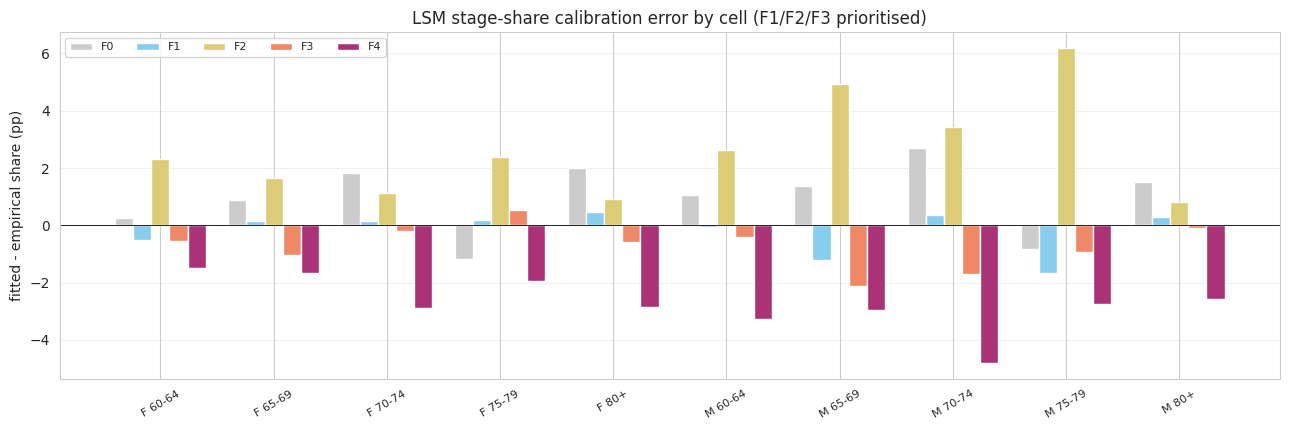

In [5]:
fs = fits.sort_values(['sex', 'age_start']).reset_index(drop=True)
labels = [f"{r['sex'][:1]} {r['age_group']}" for _, r in fs.iterrows()]
x = np.arange(len(fs)); wbar = 0.16
fig, ax = plt.subplots(figsize=(13, 4.4))
colors = ['#cccccc', '#88ccee', '#ddcc77', '#ee8866', '#aa3377']
for i, (st, c) in enumerate(zip(L.LSM_STAGES, colors)):
    err = (fs[f'{st}_fit'] - fs[f'{st}_emp']) * 100
    ax.bar(x + (i - 2) * wbar, err, wbar, color=c, label=st)
ax.axhline(0, color='k', lw=0.6); ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, fontsize=8)
ax.set_ylabel('fitted - empirical share (pp)')
ax.set_title('LSM stage-share calibration error by cell (F1/F2/F3 prioritised)')
ax.legend(ncols=5, fontsize=8); ax.grid(True, alpha=0.3, axis='y'); fig.tight_layout(); plt.show()


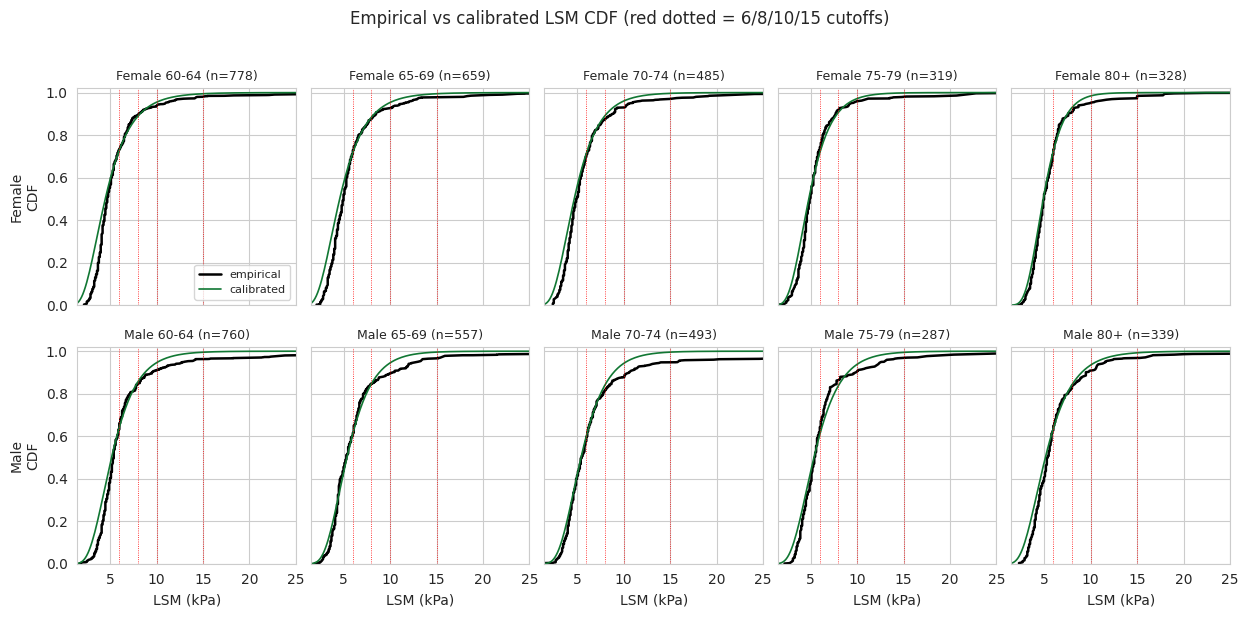

In [6]:
# CDF small multiples: empirical vs fitted lognormal, ladder cutoffs marked.
fig, axes = plt.subplots(2, len(BANDS), figsize=(2.5 * len(BANDS), 6), sharex=True, sharey=True)
for i, sex in enumerate(['Female', 'Male']):
    for j, (lo, hi, lab) in enumerate(BANDS):
        ax = axes[i, j]
        sub = lsm60[(lsm60['sex'] == sex) & (lsm60['age_start'] == lo)]
        f = fits[(fits['sex'] == sex) & (fits['age_start'] == lo)]
        if len(sub) < 30 or len(f) == 0:
            ax.set_axis_off(); continue
        f = f.iloc[0]
        y, w = sub['LSM_KPA'].values, sub['MEC_WT_POOL'].values
        o = np.argsort(y); ax.plot(y[o], np.cumsum(w[o]) / w.sum(), color='black', lw=1.8, label='empirical')
        grid = np.linspace(1.5, 30, 200)
        ax.plot(grid, stats.lognorm.cdf(grid, f['sigma'], scale=np.exp(f['mu'])),
                color='#117733', lw=1.2, label='calibrated')
        for c in L.LSM_CUTOFFS:
            ax.axvline(c, color='red', ls=':', lw=0.6)
        ax.set_title(f"{sex} {lab} (n={int(f['n'])})", fontsize=9)
        ax.set_xlim(1.5, 25); ax.set_ylim(0, 1.02)
        if j == 0: ax.set_ylabel(f'{sex}\nCDF')
        if i == 1: ax.set_xlabel('LSM (kPa)')
        if i == 0 and j == 0: ax.legend(fontsize=8, loc='lower right')
fig.suptitle('Empirical vs calibrated LSM CDF (red dotted = 6/8/10/15 cutoffs)', y=1.02)
fig.tight_layout(); plt.show()


## 5. Write outputs

Three artifacts to `outputs/`:

- **`liver_stiffness_age_sex_lognormal.csv`** - the LSM loader table. Keeps the
  backward-compatible `mean_kpa`, `sd_kpa`, `f4_share_target` columns (now
  calibration moments and the F4>=15 share) and adds empirical + fitted stage
  shares, effective N, and provenance. Notebook 05 extends it over the skeleton.
- **`cap_age_sex_distribution.csv`** - CAP `(cap_mean, cap_sd)` per cell, family,
  and empirical/fitted steatosis-grade shares.
- **`lsm_cap_calibration.meta.json`** - cutoff ladders, stage weights, and the
  calibration objective, so the share columns are interpretable and reproducible.


In [7]:
OUT = Path('outputs'); OUT.mkdir(exist_ok=True)

lsm_out = fits.copy()
lsm_out['f4_share_target'] = lsm_out['F4_emp']          # backward-compatible column
lsm_out['lsm_dist_family'] = 'lognormal'
lsm_out['source'] = 'fitted'
lsm_cols = (['sex', 'age_start', 'age_end', 'age_group', 'top_coded', 'source',
             'lsm_dist_family', 'mean_kpa', 'sd_kpa', 'f4_share_target', 'n', 'n_eff', 'ks']
            + [f'{s}_emp' for s in L.LSM_STAGES] + [f'{s}_fit' for s in L.LSM_STAGES])
lsm_out = lsm_out[lsm_cols].rename(columns={f'{s}_emp': f'lsm_{s.lower()}_share' for s in L.LSM_STAGES}
                                  | {f'{s}_fit': f'lsm_{s.lower()}_fit' for s in L.LSM_STAGES})
lsm_path = OUT / 'liver_stiffness_age_sex_lognormal.csv'
lsm_out.round(6).to_csv(lsm_path, index=False)
print(f'wrote {lsm_path} ({len(lsm_out)} rows)')

cap_out = caps.copy()
cap_out['source'] = 'fitted'
cap_cols = (['sex', 'age_start', 'age_end', 'age_group', 'top_coded', 'source',
             'cap_dist_family', 'cap_mean', 'cap_sd', 'n', 'n_eff']
            + [f'{g}_emp' for g in L.CAP_GRADES] + [f'{g}_fit' for g in L.CAP_GRADES])
cap_out = cap_out[cap_cols].rename(columns={f'{g}_emp': f'cap_{g.lower()}_share' for g in L.CAP_GRADES}
                                  | {f'{g}_fit': f'cap_{g.lower()}_fit' for g in L.CAP_GRADES})
cap_path = OUT / 'cap_age_sex_distribution.csv'
cap_out.round(6).to_csv(cap_path, index=False)
print(f'wrote {cap_path} ({len(cap_out)} rows)')

meta = L.write_meta(OUT / 'lsm_cap_calibration.meta.json', extra={
    'fitted_age_range': '60+ (5-year bands, 80+ terminal); sub-60 forward-filled in notebook 05',
    'n_pooled_lsm_60plus': int(len(lsm60)),
    'smoothing': 'per-cutoff cumulative share, logit space, effective-N weighted quadratic in age',
})
print(f"wrote {OUT / 'lsm_cap_calibration.meta.json'}")
print()
print(lsm_out[['sex', 'age_group', 'mean_kpa', 'sd_kpa', 'f4_share_target']].round(3).to_string(index=False))


wrote outputs/liver_stiffness_age_sex_lognormal.csv (10 rows)
wrote outputs/cap_age_sex_distribution.csv (10 rows)
wrote outputs/lsm_cap_calibration.meta.json

   sex age_group  mean_kpa  sd_kpa  f4_share_target
Female     60-64     5.022   2.516            0.020
Female     65-69     5.110   2.508            0.022
Female     70-74     5.159   2.335            0.032
Female     75-79     5.180   2.064            0.021
Female       80+     5.192   1.765            0.029
  Male     60-64     5.622   2.416            0.037
  Male     65-69     5.793   2.345            0.034
  Male     70-74     5.858   2.361            0.053
  Male     75-79     5.824   2.457            0.033
  Male       80+     5.667   2.625            0.033


## Caveats and handoff notes

- **`mean_kpa` / `sd_kpa` are calibration moments**, not the empirical arithmetic
  mean/SD -- they are the back-transformed moments of the stage-share-calibrated
  lognormal. The empirical moments are in notebook 02.
- **Ladder alignment.** These distributions are calibrated to the 6/8/10/15 kPa
  ladder. The consuming simulation should route on the *same* cutoffs; if it still
  bins F4 at 12.5 kPa, its realised cirrhosis share will differ from
  `f4_share_target` (which is the >=15 kPa share). Align the ladders on handoff.
- **F2 shoulder.** A unimodal lognormal cannot reproduce the empirical F2<F3
  pattern in some male cells; the residual is quantified in notebook 06. The only
  exact alternative is a categorical stage vector, which needs a downstream change
  (out of scope here).
- **CAP** is moment-matched only; the grade-share columns are descriptive.
- Weights halved for pooling; complete-exam selection uncorrected; age top-coded at 80.
